In [17]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *
from quantumScarsPlotting import *

5.440602833323251e-29


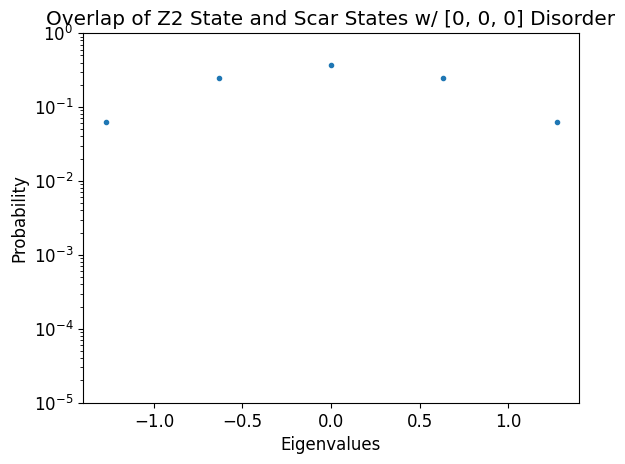

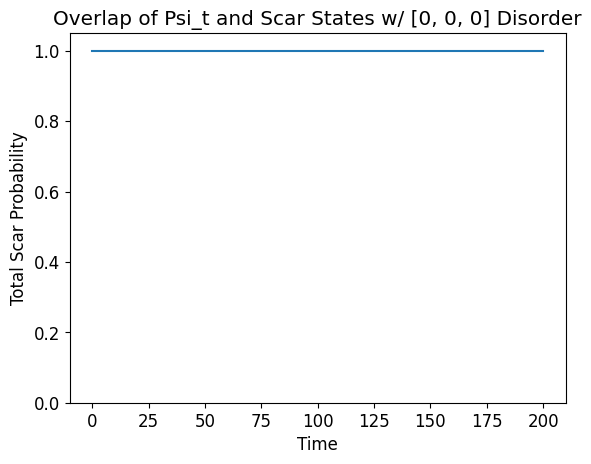

In [18]:
N = 4
N2 = N // 2

H_zeroes = np.zeros((2, 2), dtype=int)
Hx, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
Hy = get_blah(H_zeroes, N, basisList, N_dis=None, ham_disorder=[0, 1, 0], fixed_seed=False)
Hz, _ = get_scar_H1(N, basisList)

xeigvals = Hx.eigenenergies()
yeigvals = Hy.eigenenergies()
zeigvals = Hz.eigenenergies()

Hx = Hx / np.max(xeigvals) * N2
xeigvals, xeigstates = Hx.eigenstates()

Hy = Hy / np.max(yeigvals) * N2
yeigvals = Hy.eigenstates()

Hz = Hz / np.max(zeigvals) * N2
zeigvals = Hz.eigenstates()

# print(xeigvals)
# print(yeigvals)
# print(zeigvals)

threshold = 10 ** -14

zeros_eigenstates = []
for i, energies in enumerate(xeigvals):
    if -threshold < energies < threshold:
        zeros_eigenstates.append(xeigstates[i])

numpy_zeros_eigenstates = []
for better in zeros_eigenstates:
    numpy_zeros_eigenstates.append(better.full().T[0])
numpy_zeros_eigenstates = np.array(numpy_zeros_eigenstates)

# Hx_zeroes = np.linalg.multi_dot([np.conj(numpy_zeros_eigenstates), Hx.full(), numpy_zeros_eigenstates.T])
# Hy_zeroes = np.linalg.multi_dot([np.conj(numpy_zeros_eigenstates), Hy.full(), numpy_zeros_eigenstates.T])
# Hz_zeroes = np.linalg.multi_dot([np.conj(numpy_zeros_eigenstates), Hz.full(), numpy_zeros_eigenstates.T])

S2 = qt.Qobj(Hx*Hx + Hy*Hy + Hz*Hx)
S2_proj = qt.Qobj(np.linalg.multi_dot([np.conj(numpy_zeros_eigenstates), S2.full(), numpy_zeros_eigenstates.T]))

seigvals, seigstates = S2_proj.eigenstates()
max_s_val = seigvals[-1]
max_s_state = seigstates[-1]

somewhere = np.zeros(len(basisList))
for i, entries in enumerate(max_s_state.full().T[0]):
    somewhere = somewhere + (numpy_zeros_eigenstates[i] * entries)
somewhere = qt.Qobj(somewhere)

# print(max_s_state.dag() * Hx * max_s_state)
# print(seigvals)

tlist = np.linspace(0, 200, 400)
args = {"A":0.1, "omega":0.1}
scarIndices, scarStates = giveMeScarOverlap_name(N, psi0, tlist, disorder=[0, 0, 0], plot_scars=True, reals=1, args=args)

number of zero-energy states: 7
S2 eigenvalues:
[-6.63815524e-16  1.94096323e+00  1.94096323e+00  4.23994741e+00
  1.09002110e+01  1.09002110e+01  2.10535603e+01]
max S2 value: 21.05356032369187
number of max-S2 states: 1


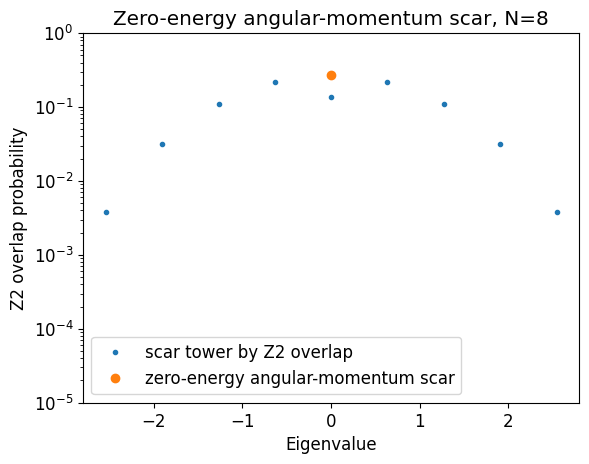

In [2]:
import numpy as np
import qutip as qt
import matplotlib.pyplot as plt
from quantumScarFunctions import *
from quantumScarsPlotting import *

N = 8
N2 = N // 2

Hx, eigenvalues, eigenstates, psi0, basisList = get_scar_ham(N)
Hy = get_Hy(N, basisList)
Hz, _ = get_scar_H1(N, basisList)

xeigvals = Hx.eigenenergies()
yeigvals = Hy.eigenenergies()
zeigvals = Hz.eigenenergies()

Hx = Hx / np.max(xeigvals) * N2
Hy = Hy / np.max(yeigvals) * N2
Hz = Hz / np.max(zeigvals) * N2

xeigvals, xeigstates = Hx.eigenstates()
yeigvals, yeigstates = Hy.eigenstates()
zeigvals, zeigstates = Hz.eigenstates()

# ----------------------------
# Find zero-energy subspace of Hx
# ----------------------------

threshold = 1e-14

zeros_eigenstates = []

for i, energy in enumerate(xeigvals):
    if abs(energy) < threshold:
        zeros_eigenstates.append(xeigstates[i])

if len(zeros_eigenstates) == 0:
    raise ValueError("No zero-energy states found. Try increasing threshold.")

# P has rows = zero-energy basis vectors
P = []

for state in zeros_eigenstates:
    P.append(state.full().flatten())

P = np.array(P)

# ----------------------------
# Build projected angular momentum S^2
#
# Important:
# Use P (Sx^2 + Sy^2 + Sz^2) P^\dagger
# NOT (P Sx P^\dagger)^2 + ...
# ----------------------------

S2_full = (
    Hx.full() @ Hx.full()
    + Hy.full() @ Hy.full()
    + Hz.full() @ Hz.full()
)

S2_zeroes = np.conj(P) @ S2_full @ P.T

S2 = qt.Qobj(S2_zeroes)

seigvals, seigstates = S2.eigenstates()

# ----------------------------
# Take the maximum-S2 subspace
# ----------------------------

s_tol = 1e-10
max_s_val = seigvals[-1]

max_s_states = []

for i, val in enumerate(seigvals):
    if abs(val - max_s_val) < s_tol:
        max_s_states.append(seigstates[i])

# ----------------------------
# Reconstruct max-S2 states back into full constrained Hilbert space
# ----------------------------

candidates = []

for s_state in max_s_states:
    candidate_np = s_state.full().flatten() @ P
    candidate = qt.Qobj(candidate_np)
    candidate = candidate / candidate.norm()
    candidates.append(candidate)

# ----------------------------
# Pick the Z2-visible state inside the max-S2 scar manifold
#
# This is NOT projecting Z2 into the full zero-energy subspace.
# This projects Z2 only into the angular-momentum-selected max-S2 subspace.
# ----------------------------

scar = 0 * candidates[0]

for candidate in candidates:
    coeff = candidate.dag() * psi0
    scar += coeff * candidate

if scar.norm() < 1e-14:
    print("WARNING: Z2 has almost zero overlap with the max-S2 zero-energy subspace.")
    print("Try checking operator definitions or degeneracies.")
else:
    scar = scar / scar.norm()

# ----------------------------
# Diagnostics
# ----------------------------

z2_overlap = np.abs(psi0.dag() * scar) ** 2

# ----------------------------
# Plot ordinary scar tower overlaps plus zero-energy angular-momentum scar
# ----------------------------

sections = np.linspace(eigenvalues[0] - 0.5, eigenvalues[-1] + 0.5, N + 2)

scarIndices = []
scarStates = []

for i in range(len(sections) - 1):

    eigenSection = []

    for k in range(len(eigenvalues)):
        if (eigenvalues[k] > sections[i]) and (eigenvalues[k] < sections[i + 1]):
            eigenSection.append(k)

    if len(eigenSection) == 0:
        continue

    highestOverlap = np.abs(psi0.dag() * eigenstates[eigenSection[0]]) ** 2
    highestOverlapIndex = eigenSection[0]

    for m in range(1, len(eigenSection)):
        overlap = np.abs(psi0.dag() * eigenstates[eigenSection[m]]) ** 2

        if overlap > highestOverlap:
            highestOverlap = overlap
            highestOverlapIndex = eigenSection[m]

    scarIndices.append(highestOverlapIndex)

scarStates = [eigenstates[i] for i in scarIndices]

amplitudes = []
eigenvalueIndices = []

for i in scarIndices:
    amplitudes.append(psi0.dag() * eigenstates[i])
    eigenvalueIndices.append(eigenvalues[i])

plt.figure()
plt.plot(eigenvalueIndices, np.abs(amplitudes) ** 2, ".", label="scar tower by Z2 overlap")
plt.plot(0, z2_overlap, ".", markersize=12, label="zero-energy angular-momentum scar")
plt.yscale("log")
plt.ylim(1e-5, 1)
plt.xlabel("Eigenvalue")
plt.ylabel("Z2 overlap probability")
plt.title(f"Zero-energy angular-momentum scar, N={N}")
plt.legend()
plt.show()